# SciPy Bootcamp — Week 1, Day 1

##### Probability Foundations & Distributions
##### Normal, Binomial, Poisson — scipy.stats distributions
##### Dataset: Simulated WebMD health search traffic data
##### Kaggle dataset suggestion: 'Health Search Trends' or use simulated data in this notebook
##### Q1 Create a Normal distribution with mean=120 (avg WebMD daily health searches per user session, in seconds) and std=25. Compute: (a) the probability a session lasts more than 180s, (b) the 90th percentile session length, (c) generate 1000 samples and print the mean and std.
##### Q2 Model newsletter click events as a Binomial distribution: 80,000 NYT subscribers, 18% click rate. Compute: (a) expected number of clicks, (b) P(clicks > 15,500), (c) P(clicks < 13,000). What does this tell you about campaign risk?
##### Q3 Model WebMD homepage visits per minute as Poisson(mu=420). Compute: (a) P(exactly 400 visits in a minute), (b) P(more than 500 visits — traffic spike), (c) find the 99th percentile visit count. How would you use this for capacity planning?
##### Q4 Fit a distribution to real data: generate 500 samples from an unknown distribution using np.random.lognormal(mean=1.5, sigma=0.6). Use scipy.stats to fit a lognormal distribution back to it. Print the fitted parameters and compare to the true ones.
##### Q5 Compare two distributions visually and statistically: generate 1000 samples each from Normal(50,10) and a right-skewed distribution of your choice. Use stats.probplot() to create Q-Q plots for each and stats.shapiro() to test normality. Print and interpret results.

In [1]:
from scipy import stats
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Q1 Create a Normal distribution with mean=120 (avg WebMD daily health searches per user session, in seconds) and std=25. 
# Compute: 
# (a) the probability a session lasts more than 180s, 
# (b) the 90th percentile session length, 
# (c) generate 1000 samples and print the mean and std.

In [ ]:
dist_1 = stats.norm(loc=120, scale=25)
# (a) the probability a session lasts more than 180s
print(1-dist_1.cdf(180))
# (b) the 90th percentile session length
print(dist_1.ppf(.9))

0.008197535924596155
152.03878913861502


In [5]:
# (c) generate 1000 samples and print the mean and std.
sample_1 = dist_1.rvs(size=1000)
print(sample_1.mean())
print(sample_1.std())

119.00496208324708
24.88584218582691


In [ ]:
# Q2 Model newsletter click events as a Binomial distribution: 80,000 NYT subscribers, 18% click rate. Compute: 
# (a) expected number of clicks, 
# (b) P(clicks > 15,500), 
# (c) P(clicks < 13,000). What does this tell you about campaign risk?

In [ ]:
dist_2 = stats.binom(n=80000,p=0.18)
# (a) expected number of clicks
print(dist_2.mean())
# (b) P(clicks > 15,500)
print(1 - dist_2.cdf(15500))
# (c) P(clicks < 13,000). What does this tell you about campaign risk? The campaign has high open rate so the risk is low
print(dist_2.cdf(13000))

14400.0
0.0
3.23302471626564e-39


In [ ]:
# Q3 Model WebMD homepage visits per minute as Poisson(mu=420). Compute: 
# (a) P(exactly 400 visits in a minute), 
# (b) P(more than 500 visits — traffic spike), 
# (c) find the 99th percentile visit count. How would you use this for capacity planning?

In [ ]:
dist_3 = stats.poisson(mu=420)
# (a) P(exactly 400 visits in a minute)
print(dist_3.pmf(400))
# (b) P(more than 500 visits — traffic spike)
print(1-dist_3.cdf(500))
# (c) find the 99th percentile visit count. How would you use this for capacity planning? 
print(dist_3.ppf(.99))

0.012291915952978837
6.686471653305492e-05
468.0


In [ ]:
# Q4 Fit a distribution to real data: generate 500 samples from an unknown distribution using np.random.lognormal(mean=1.5, sigma=0.6). 
# Use scipy.stats to fit a lognormal distribution back to it. Print the fitted parameters and compare to the true ones.

In [23]:
import numpy as np
from scipy import stats

sample_4 = np.random.lognormal(mean=1.5, sigma=0.6, size=500)

# Fit lognormal distribution to the data
# stats.lognorm returns: shape (sigma), loc, scale (where scale = exp(mu))
sigma_fit, loc_fit, scale_fit = stats.lognorm.fit(sample_4, floc=0)

mu_fit = np.log(scale_fit)   # convert scale back to mu

print(f"True parameters:   mu=1.5,        sigma=0.6")
print(f"Fitted parameters: mu={mu_fit:.4f}, sigma={sigma_fit:.4f}")
print(f"Difference:        mu_diff={abs(1.5 - mu_fit):.4f}, sigma_diff={abs(0.6 - sigma_fit):.4f}")

True parameters:   mu=1.5,        sigma=0.6
Fitted parameters: mu=1.4903, sigma=0.5675
Difference:        mu_diff=0.0097, sigma_diff=0.0325


In [ ]:
# Q5 Compare two distributions visually and statistically: generate 1000 samples each from Normal(50,10) and a right-skewed distribution of your choice. Use stats.probplot() to create Q-Q plots for each and stats.shapiro() to test normality. Print and interpret results.

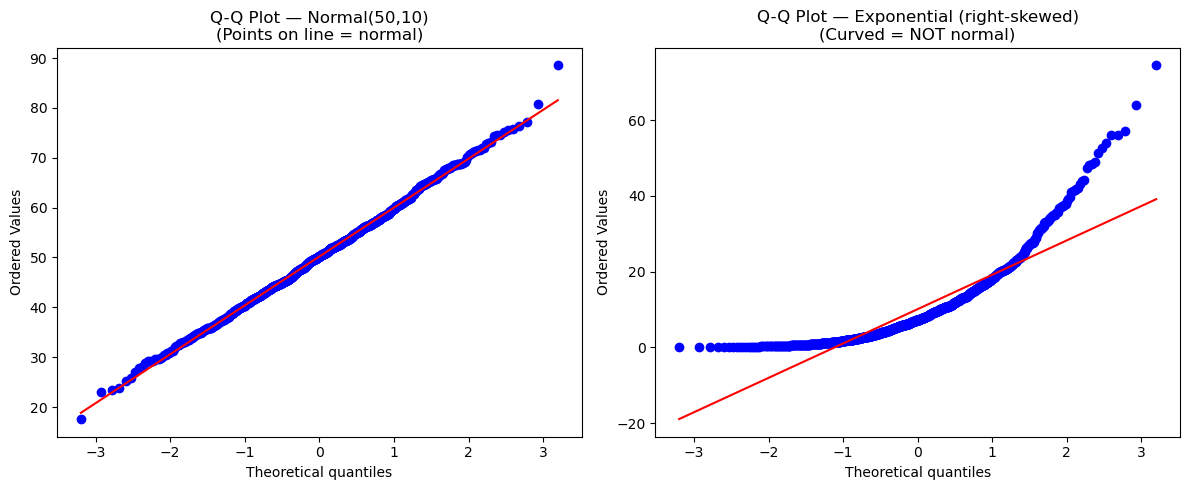

Normal samples:  W=0.9986, p=0.6273 → Normal ✅
Skewed samples:  W=0.8156, p=0.0000 → Not normal ❌


In [24]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate samples
normal_samples  = np.random.normal(50, 10, 1000)
skewed_samples  = np.random.exponential(scale=10, size=1000)  # right-skewed

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plots
stats.probplot(normal_samples, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot — Normal(50,10)\n(Points on line = normal)')

stats.probplot(skewed_samples, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot — Exponential (right-skewed)\n(Curved = NOT normal)')

plt.tight_layout()
plt.show()

# Shapiro-Wilk normality test
stat_n, p_n = stats.shapiro(normal_samples)
stat_s, p_s = stats.shapiro(skewed_samples)

print(f"Normal samples:  W={stat_n:.4f}, p={p_n:.4f} → {'Normal ✅' if p_n > 0.05 else 'Not normal ❌'}")
print(f"Skewed samples:  W={stat_s:.4f}, p={p_s:.4f} → {'Normal ✅' if p_s > 0.05 else 'Not normal ❌'}")

How to read a Q-Q plot: 
if the points follow the diagonal red line closely → the data is normal. 
If they curve away (like an S-shape or banana) → it's not normal. 
The exponential will show a clear upward curve at the right tail — that's the skewness showing up visually.

In [ ]:
# 1. Create your right-skewed data
scale_val = 10
right_skewed = np.random.exponential(scale=scale_val, size=1000)

# 2. Flip it to make it left-skewed
# Subtracting the values from a constant (like the max) flips the tail
left_skewed = np.max(right_skewed) - right_skewed

# Shapiro-Wilk test
The Shapiro-Wilk test is a "lie detector" for the Normal Distribution. 

It asks the data: "How likely is it that you came from a perfect Bell Curve?"

When you run stats.shapiro(data), it gives you two numbers:

stat_n, p_n = stats.shapiro(normal_samples)
stat_s, p_s = stats.shapiro(skewed_samples)

1. stat (The Test Statistic)
Think of this as a "Similarity Score" between 0 and 1.
The closer it is to 1.0, the more your data "looks" like a perfect Bell Curve.

stat_n (Normal) will likely be around 0.99, while stat_s (Skewed) will be much lower (like 0.80).


2. p (The p-value) — The Most Important Number
This is the "Verdict." 
In statistics, we usually use a threshold of 0.05.
If p > 0.05: "We cannot prove it's NOT normal." (The data passes the test).
If p < 0.05: "We are 95% sure this is NOT a normal distribution." (The data fails the test).